In [5]:
import pymap3d as pm

In [6]:
pm.geodetic2enu(54.9871429453, 82.8652447510, 87.6780,  54.987143279,   82.865249156,    88.4816)

(np.float64(-0.2819881391696501),
 np.float64(-0.0371490851295635),
 np.float64(-0.8036000050771098))

In [11]:
pm.geodetic2enu(54.9871429453, 82.8652447510, 87.6780,  54.987143279,   82.865249156,    88.4816) # 300

(np.float64(-0.2819881391696501),
 np.float64(-0.0371490851295635),
 np.float64(-0.8036000050771098))

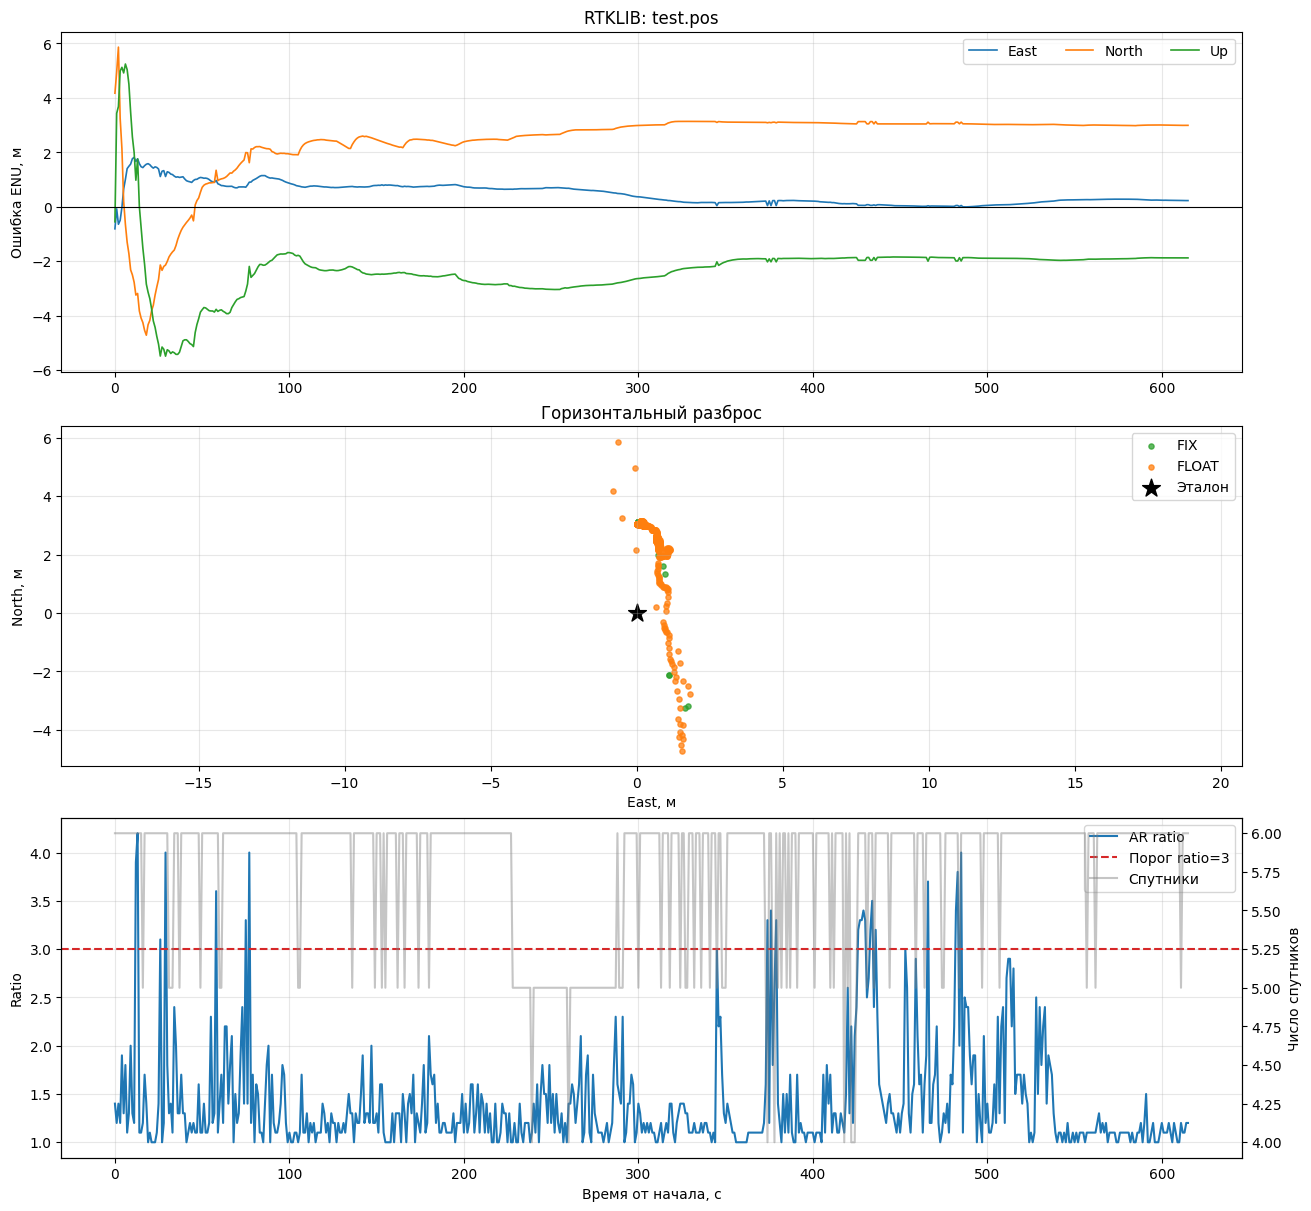

Эпох: 616, FIX: 3.7%
   FIX: n=  23, mean ENU=(+0.394, +1.918, -2.132) м, RMS H/3D=(2.979, 3.955) м
 FLOAT: n= 593, mean ENU=(+0.477, +2.422, -2.281) м, RMS H/3D=(2.831, 3.816) м


In [8]:
from pathlib import Path
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt

# Эталонная координата: при необходимости измените эти три значения.
REF_LAT = 54.9871429453
REF_LON = 82.8652447510
REF_H = 87.6780

pos_path = Path("test.pos")
if not pos_path.exists():
    pos_path = Path("/Users/sergeidolin/RTKLIB/app/consapp/rnx2rtkp/gcc/test.pos")

# Чтение LLH-формата RTKLIB без pandas.
rows = []
with pos_path.open(encoding="utf-8", errors="replace") as f:
    for line in f:
        if not line.strip() or line.lstrip().startswith("%"):
            continue
        p = line.split()
        if len(p) < 15:
            continue
        rows.append((
            datetime.strptime(p[0] + " " + p[1], "%Y/%m/%d %H:%M:%S.%f"),
            float(p[2]), float(p[3]), float(p[4]),
            int(p[5]), int(p[6]), float(p[14])
        ))

if not rows:
    raise ValueError(f"В {pos_path} не найдены решения RTKLIB")

time = np.array([r[0] for r in rows])
lat = np.array([r[1] for r in rows])
lon = np.array([r[2] for r in rows])
height = np.array([r[3] for r in rows])
quality = np.array([r[4] for r in rows])
nsat = np.array([r[5] for r in rows])
ratio = np.array([r[6] for r in rows])
elapsed = np.array([(t - time[0]).total_seconds() for t in time])

# WGS-84: геодезические координаты -> ECEF -> локальные ошибки ENU.
def geodetic_to_ecef(lat_deg, lon_deg, h):
    a = 6378137.0
    e2 = 6.6943799901413165e-3
    phi = np.deg2rad(lat_deg)
    lam = np.deg2rad(lon_deg)
    n = a / np.sqrt(1.0 - e2 * np.sin(phi) ** 2)
    x = (n + h) * np.cos(phi) * np.cos(lam)
    y = (n + h) * np.cos(phi) * np.sin(lam)
    z = (n * (1.0 - e2) + h) * np.sin(phi)
    return x, y, z

x, y, z = geodetic_to_ecef(lat, lon, height)
x0, y0, z0 = geodetic_to_ecef(REF_LAT, REF_LON, REF_H)
dx, dy, dz = x - x0, y - y0, z - z0
phi0, lam0 = np.deg2rad(REF_LAT), np.deg2rad(REF_LON)
east = -np.sin(lam0) * dx + np.cos(lam0) * dy
north = (-np.sin(phi0) * np.cos(lam0) * dx
         -np.sin(phi0) * np.sin(lam0) * dy + np.cos(phi0) * dz)
up = (np.cos(phi0) * np.cos(lam0) * dx
      +np.cos(phi0) * np.sin(lam0) * dy + np.sin(phi0) * dz)
horizontal = np.hypot(east, north)
error_3d = np.sqrt(east**2 + north**2 + up**2)

labels = {1: "FIX", 2: "FLOAT", 3: "SBAS", 4: "DGPS", 5: "SINGLE", 6: "PPP"}
colors = {1: "tab:green", 2: "tab:orange", 3: "tab:blue", 4: "tab:purple", 5: "tab:red", 6: "tab:brown"}

fig, ax = plt.subplots(3, 1, figsize=(13, 12), constrained_layout=True)

ax[0].plot(elapsed, east, label="East", lw=1.2)
ax[0].plot(elapsed, north, label="North", lw=1.2)
ax[0].plot(elapsed, up, label="Up", lw=1.2)
ax[0].axhline(0, color="black", lw=0.8)
ax[0].set(ylabel="Ошибка ENU, м", title=f"RTKLIB: {pos_path.name}")
ax[0].grid(True, alpha=0.3); ax[0].legend(ncol=3)

for q in np.unique(quality):
    m = quality == q
    ax[1].scatter(east[m], north[m], s=14, alpha=0.75,
                  color=colors.get(q, "gray"), label=labels.get(q, f"Q={q}"))
ax[1].scatter(0, 0, marker="*", s=180, color="black", label="Эталон")
ax[1].set(xlabel="East, м", ylabel="North, м", title="Горизонтальный разброс")
ax[1].axis("equal"); ax[1].grid(True, alpha=0.3); ax[1].legend()

ax[2].plot(elapsed, ratio, color="tab:blue", label="AR ratio")
ax[2].axhline(3.0, color="tab:red", ls="--", label="Порог ratio=3")
ax[2].set(xlabel="Время от начала, с", ylabel="Ratio")
ax2 = ax[2].twinx()
ax2.plot(elapsed, nsat, color="tab:gray", alpha=0.45, label="Спутники")
ax2.set_ylabel("Число спутников")
lines = ax[2].lines + ax2.lines
ax[2].legend(lines, [line.get_label() for line in lines], loc="upper right")
ax[2].grid(True, alpha=0.3)
plt.show()

print(f"Эпох: {len(rows)}, FIX: {np.mean(quality == 1):.1%}")
for q in np.unique(quality):
    m = quality == q
    print(f"{labels.get(q, f'Q={q}'):>6}: n={m.sum():4d}, "
          f"mean ENU=({east[m].mean():+.3f}, {north[m].mean():+.3f}, {up[m].mean():+.3f}) м, "
          f"RMS H/3D=({np.sqrt(np.mean(horizontal[m]**2)):.3f}, "
          f"{np.sqrt(np.mean(error_3d[m]**2)):.3f}) м")
